# 01 · Entendimento do problema e das fontes

**Tech Challenge — Fase 2 · Pipeline híbrida para análise da alfabetização no Brasil**

O Compromisso Nacional Criança Alfabetizada mobiliza União, estados e municípios com uma
meta clara: toda criança alfabetizada até o fim do 2º ano do ensino fundamental. A régua
é o **Indicador Criança Alfabetizada** — o percentual de estudantes do 2º ano da rede
pública que atinge **743 pontos na escala de proficiência do Saeb**, ponto de corte
definido pela Pesquisa Alfabetiza Brasil de 2023.

Este notebook responde três perguntas antes de qualquer linha de pipeline:

1. **Que dado existe, e de quem ele é?**
2. **O que nele é real e o que é reconstruído?**
3. **Que defeitos ele tem — e como sabemos que a pipeline os tratou?**

In [1]:
import sys
from pathlib import Path

# Caminho relativo: o notebook encontra o projeto a partir da própria posição,
# então funciona em qualquer máquina, sem editar nada.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
print("Raiz do projeto:", RAIZ.name)

Raiz do projeto: tc2


## 1. As seis entidades do desafio

O desafio define as fontes a integrar. Cada uma virou um arquivo em `data/raw/`,
versionado no repositório — sem isso, ninguém reproduz o resultado.

In [2]:
raw = RAIZ / "data" / "raw"
manifesto = __import__('json').loads((raw / "_manifesto.json").read_text(encoding="utf-8"))

resumo = pd.DataFrame([
    {"arquivo": nome, "registros": info["registros"], "colunas": len(info["colunas"])}
    for nome, info in manifesto["arquivos"].items()
]).sort_values("registros", ascending=False)
resumo

,arquivo,registros,colunas
6,aluno.csv,60240,11
5,meta_alfabetizacao_municipio.csv,16779,10
1,municipio.csv,5593,10
2,contexto_socioeconomico_municipio.csv,5564,24
4,meta_alfabetizacao_uf.csv,216,7
0,uf.csv,27,7
3,meta_alfabetizacao_brasil.csv,8,7


## 2. Proveniência — o que é real e o que é reconstruído

Esta é a seção mais importante do notebook. Trabalhar com dado público exige dizer,
sem rodeio, de onde veio cada número. O manifesto declara isso arquivo a arquivo, e o
rótulo viaja com o dado até a camada Gold, nas colunas `origem_indicador` e `origem_meta`.

In [3]:
proveniencia = pd.DataFrame(
    [{"arquivo": k, "proveniência": v} for k, v in manifesto["proveniencia"].items()]
)
proveniencia.style.hide(axis="index")

arquivo,proveniência
uf.csv,REAL (IBGE)
municipio.csv,REAL (IBGE) + defeitos controlados
contexto_socioeconomico_municipio.csv,"REAL (Atlas do Desenvolvimento Humano, Censo 2010)"
meta_alfabetizacao_brasil.csv,REAL (INEP/MEC) + interpolação da trajetória oficial
meta_alfabetizacao_uf.csv,REAL (INEP/MEC) para o indicador; metas derivadas por regra
meta_alfabetizacao_municipio.csv,SIMULADO calibrado pela média real de cada UF
aluno.csv,SIMULADO calibrado pelo indicador municipal (pseudonimizado)


### Por que o grão municipal é simulado

O INEP publica o resultado por município em consulta interativa, sem arquivo aberto para
download. Em vez de inventar números, a simulação é **calibrada**:

- cada município recebe um escore a partir das suas variáveis socioeconômicas **reais**
  (IDHM educação, % de crianças pobres, analfabetismo, atraso escolar), vindas do
  Atlas do Desenvolvimento Humano;
- esse escore é reescalado até que a **média ponderada por matrículas de cada UF
  reproduza o valor real publicado pelo INEP** para aquela UF.

O resultado é auditável: a coluna `divergencia_pp` da tabela `gold.meta_vs_realizado_uf`
mede exatamente o quanto o agregado dos municípios se afasta do publicado.

## 3. A série real do indicador

In [4]:
from src.ingestao import fontes_oficiais as fo

nacional = pd.DataFrame({
    "ano": list(fo.INDICADOR_BRASIL),
    "indicador_pct": list(fo.INDICADOR_BRASIL.values()),
})
nacional["meta_pct"] = [fo.meta_brasil(a)[0] if a >= 2024 else None for a in nacional["ano"]]
print(nacional.to_string(index=False))

metas = pd.DataFrame({
    "ano": sorted(fo.META_BRASIL_PUBLICADA) + [2027, 2028, 2029],
    })
metas["meta_pct"] = [fo.meta_brasil(a)[0] for a in metas["ano"]]
metas["origem"] = [fo.meta_brasil(a)[1] for a in metas["ano"]]
metas.sort_values("ano")

 ano  indicador_pct  meta_pct
2023           55.9       NaN
2024           59.2      59.9
2025           66.0      64.0


,ano,meta_pct,origem
0,2024,59.9,INEP_PUBLICADO
1,2025,64.0,INEP_PUBLICADO
2,2026,67.0,INEP_PUBLICADO
4,2027,70.2,INTERPOLADO_TRAJETORIA_OFICIAL
5,2028,73.5,INTERPOLADO_TRAJETORIA_OFICIAL
6,2029,76.8,INTERPOLADO_TRAJETORIA_OFICIAL
3,2030,80.0,INEP_PUBLICADO


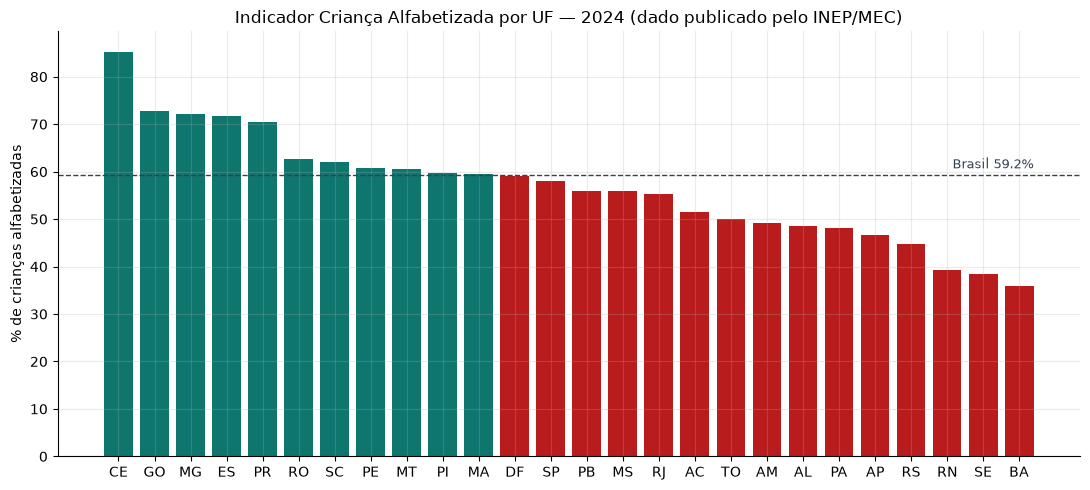

UFs sem valor publicado em 2024: ['RR']


In [5]:
uf = pd.DataFrame([
    {"sigla_uf": sigla, **{f"ind_{ano}": valor for ano, valor in anos.items()}}
    for sigla, anos in fo.INDICADOR_UF.items()
]).sort_values("ind_2024", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
dados = uf.dropna(subset=["ind_2024"])
cores = ["#0f766e" if v >= fo.INDICADOR_BRASIL[2024] else "#b91c1c" for v in dados["ind_2024"]]
ax.bar(dados["sigla_uf"], dados["ind_2024"], color=cores)
ax.axhline(fo.INDICADOR_BRASIL[2024], color="#334155", linestyle="--", linewidth=1)
ax.text(25.4, fo.INDICADOR_BRASIL[2024] + 1.5, f"Brasil {fo.INDICADOR_BRASIL[2024]}%",
        ha="right", fontsize=9, color="#334155")
ax.set_title("Indicador Criança Alfabetizada por UF — 2024 (dado publicado pelo INEP/MEC)")
ax.set_ylabel("% de crianças alfabetizadas")
plt.tight_layout(); plt.show()

print("UFs sem valor publicado em 2024:",
      [s for s, a in fo.INDICADOR_UF.items() if a.get(2024) is None])

O gráfico já mostra o problema central: **a distância entre Ceará (85,3%) e Bahia (36,0%)
é de quase 50 pontos percentuais** dentro do mesmo país e do mesmo ano.

E há uma ausência que a pipeline precisa respeitar: **Roraima não teve coleta divulgada**.
O valor permanece nulo, com a flag `indicador_disponivel = false`. Imputar a média
nacional aqui produziria um número inventado num painel de política pública.

## 4. Os defeitos que a pipeline precisa tratar

`src/ingestao/preparar_raw.py` injeta defeitos controlados — duplicidade, texto
inconsistente, valores impossíveis — para que a limpeza da camada Silver seja
**verificável**, e não uma promessa no README.

In [6]:
municipio = pd.read_csv(raw / "municipio.csv")
aluno = pd.read_csv(raw / "aluno.csv")

print(f"municipio.csv: {len(municipio):,} linhas | {municipio['id_municipio'].nunique():,} ids únicos "
      f"-> {len(municipio) - municipio['id_municipio'].nunique()} duplicados")
print(f"latitude nula: {municipio['latitude'].isna().sum()} municípios")

sujos = municipio[municipio["nome_municipio"].str.contains(r"^\s|\s$", regex=True, na=False)
                  | (municipio["nome_municipio"] == municipio["nome_municipio"].str.upper())]
print(f"nomes com caixa ou espaçamento irregular: {len(sujos)}")
print(sujos["nome_municipio"].head(5).tolist())

print(f"\naluno.csv: proficiência ausente = {aluno['proficiencia_saeb'].isna().sum()} | "
      f"impossível (< 0) = {(aluno['proficiencia_saeb'] < 0).sum()}")

municipio.csv: 5,593 linhas | 5,571 ids únicos -> 22 duplicados
latitude nula: 12 municípios
nomes com caixa ou espaçamento irregular: 166
['  Marechal Thaumaturgo  ', '  Rio Branco  ', 'MANAUS', '  Augusto Corrêa  ', 'BREU BRANCO']

aluno.csv: proficiência ausente = 40 | impossível (< 0) = 15


## 5. O contexto socioeconômico (fonte externa)

O desafio sugere enriquecer a base com contexto socioeconômico. Usamos o **Atlas do
Desenvolvimento Humano no Brasil** (PNUD/Ipea/FJP, Censo 2010) — dado real, por município,
que depois sustenta a análise de desigualdade e a feature store do modelo.

In [7]:
contexto = pd.read_csv(raw / "contexto_socioeconomico_municipio.csv")
print(f"{len(contexto):,} municípios | {contexto.shape[1]} variáveis")
contexto[["idhm", "idhm_educacao", "renda_per_capita", "pct_criancas_pobres",
          "taxa_analfabetismo_15mais", "populacao_total"]].describe().round(2)

5,564 municípios | 24 variáveis


,idhm,idhm_educacao,renda_per_capita,pct_criancas_pobres,taxa_analfabetismo_15mais,populacao_total
count,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,493.65,33.73,16.16,34282.48
std,0.07,0.09,243.27,21.99,9.84,203130.57
min,0.42,0.21,96.25,0.00,0.95,805.00
25%,0.60,0.49,281.14,13.48,8.08,5234.00
50%,0.66,0.56,467.74,30.03,13.11,10935.00
75%,0.72,0.63,650.63,54.04,24.31,23446.25
max,0.86,0.82,2043.74,84.66,44.40,11253503.00


### O que esperamos encontrar

A hipótese que orienta a camada Gold: **território e condição socioeconômica explicam boa
parte da variação do indicador**. Se isso se confirmar, a pipeline não serve só para
reportar — serve para **priorizar** onde o apoio técnico faz mais diferença.

O notebook `03_camada_gold_analises` testa essa hipótese sobre o dado já processado.